# UniXcoder (frozen) — 2 giai đoạn: Trích embedding → So sánh classifier

**Giai đoạn 1.** Cho toàn bộ dữ liệu qua UniXcoder **đóng băng** *một lần*, mean-pooling → vector 768-d, lưu ra `.npz`.

**Giai đoạn 2.** Nạp lại vector và **so sánh nhiều classifier** trên *cùng một tập feature* (LogReg, Linear SVM, RBF SVM, Random Forest, XGBoost, và MLP head của bạn). Vì encoder cố định, mỗi classifier chỉ mất vài giây–vài phút → đổi/thêm thuật toán cực nhanh.

Train trên `train_downsampling` (cân bằng); đánh giá trên `validation`/`test` (phân phối gốc, lệch lớp) ⇒ nhìn **F1 / PR-AUC / MCC**, không nhìn accuracy.


In [ ]:
!pip install -q -U transformers datasets
!pip install -q xgboost

---
## GIAI ĐOẠN 1 — Trích & cache embedding

Chạy 1 lần. Sau khi có `unixcoder_embeddings.npz`, có thể bỏ qua phần này và nhảy thẳng xuống Giai đoạn 2 (nạp lại từ file). Muốn giữ qua các phiên Colab thì mount Google Drive và lưu vào đó.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer, AutoConfig
from datasets import load_dataset
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "microsoft/unixcoder-base"
MAX_LEN = 512
print("device:", device)

# (tuy chon) luu qua cac phien Colab:
from google.colab import drive; drive.mount('/content/drive')
EMB_PATH = '/content/drive/MyDrive/unixcoder_embeddings.npz'
# EMB_PATH = "unixcoder_embeddings.npz"

device: cuda
Mounted at /content/drive


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
for p in encoder.parameters():
    p.requires_grad = False   # dong bang hoan toan

def mean_pool(last_hidden_state, attention_mask):
    m = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    return (last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-9)

@torch.no_grad()
def extract(dset, batch_size=64):
    texts = dset["text"]
    labels = np.array(dset["label"], dtype=np.int64)
    feats = []
    for i in tqdm(range(0, len(texts), batch_size)):
        enc = tokenizer(texts[i:i + batch_size], truncation=True, max_length=MAX_LEN,
                        padding=True, return_tensors="pt").to(device)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
            out = encoder(**enc)
        pooled = mean_pool(out.last_hidden_state, enc["attention_mask"])
        feats.append(pooled.float().cpu().numpy().astype(np.float16))  # float16 cho nhe dia
    return np.concatenate(feats), labels

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/938k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/444k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
ds = load_dataset("AnhMinhLe/TrainingReCode")
print(ds)

X_train, y_train = extract(ds["train_downsampling"])
X_val,   y_val   = extract(ds["validation"])
X_test,  y_test  = extract(ds["test"])

print("shapes:", X_train.shape, X_val.shape, X_test.shape)
np.savez(EMB_PATH, X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)
print("Saved ->", EMB_PATH)

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/682 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/188M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/189M [00:00<?, ?B/s]

data/train_downsampling-00000-of-00001.p(…):   0%|          | 0.00/121M [00:00<?, ?B/s]

...

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 451792
    })
    train_downsampling: Dataset({
        features: ['text', 'label'],
        num_rows: 101056
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 56474
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 56474
    })
})


  0%|          | 0/1579 [00:00<?, ?it/s]

  0%|          | 0/883 [00:00<?, ?it/s]

  0%|          | 0/883 [00:00<?, ?it/s]

shapes: (101056, 768) (56474, 768) (56474, 768)
Saved -> /content/drive/MyDrive/unixcoder_embeddings.npz


---
## GIAI ĐOẠN 2 — So sánh classifier trên feature đã cache

In [ ]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             average_precision_score, roc_auc_score,
                             matthews_corrcoef, accuracy_score)
from xgboost import XGBClassifier

EMB_PATH = '/content/drive/MyDrive/unixcoder_embeddings.npz'   # doi neu luu o Drive
d = np.load(EMB_PATH)
X_train = d["X_train"].astype(np.float32); y_train = d["y_train"]
X_val   = d["X_val"].astype(np.float32);   y_val   = d["y_val"]
X_test  = d["X_test"].astype(np.float32);  y_test  = d["y_test"]
print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print("train balance:", np.bincount(y_train), "| test balance:", np.bincount(y_test))

# Chuan hoa: fit tren train, ap cho ca 3. (Cay thi bat bien voi scale nen vo hai)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

train/val/test: (101056, 768) (56474, 768) (56474, 768)
train balance: [50528 50528] | test balance: [53980  2494]


### MLP head của bạn — bọc thành estimator kiểu sklearn

Để head MLP `768→512→256→2` (đúng kiến trúc bạn đưa, có BatchNorm/Dropout) **chạy chung một vòng lặp** với các thuật toán khác. Nhờ vậy nó chỉ là *một dòng* trong registry bên dưới.

In [ ]:
class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=768, n_classes=2, epochs=30, lr=1e-3,
                 batch_size=256, weight_decay=1e-2, device=None):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.weight_decay = weight_decay
        self.device = device   # luu nguyen, resolve trong fit (sklearn-clone-safe)

    def _build(self):
        return nn.Sequential(
            nn.Linear(self.input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256),            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, self.n_classes),
        )

    def fit(self, X, y):
        self._dev = self.device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.classes_ = np.unique(y)
        self.net = self._build().to(self._dev)
        Xt = torch.tensor(np.asarray(X), dtype=torch.float32)
        yt = torch.tensor(np.asarray(y), dtype=torch.long)
        dl = DataLoader(TensorDataset(Xt, yt), batch_size=self.batch_size,
                        shuffle=True, drop_last=True)   # drop_last: bao ve BatchNorm
        opt = AdamW(self.net.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        self.net.train()
        for _ in range(self.epochs):
            for xb, yb in dl:
                xb, yb = xb.to(self._dev), yb.to(self._dev)
                opt.zero_grad()
                F.cross_entropy(self.net(xb), yb).backward()
                opt.step()
        return self

    @torch.no_grad()
    def predict_proba(self, X):
        self.net.eval()
        Xt = torch.tensor(np.asarray(X), dtype=torch.float32).to(self._dev)
        return torch.softmax(self.net(Xt), dim=1).cpu().numpy()

    def predict(self, X):
        return self.predict_proba(X).argmax(1)

### ⬇️ REGISTRY — chỉnh ở ĐÂY

Mỗi dòng = một thuật toán. **Thêm** classifier mới chỉ cần thêm một dòng; **tinh chỉnh** thì sửa tham số ngay tại dòng đó; **bỏ** thì comment lại.

`max_train`: giới hạn số mẫu train cho model **chậm**. RBF-SVM là `O(n²)` nên đặt 20k; để `None` nghĩa là dùng toàn bộ ~101k.

In [ ]:
MODELS = {
    "LogReg":        dict(est=LogisticRegression(max_iter=2000, C=1.0),
                          max_train=None),
    "LinearSVM":     dict(est=LinearSVC(C=1.0),
                          max_train=None),
    "RBF-SVM":       dict(est=SVC(kernel="rbf", C=1.0, gamma="scale"),
                          max_train=20000),   # O(n^2) -> subsample cho chay duoc
    "RandomForest":  dict(est=RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                     random_state=42),
                          max_train=None),
    "XGBoost":       dict(est=XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                            tree_method="hist", eval_metric="logloss",
                                            n_jobs=-1, random_state=42),
                          max_train=None),
    "MLP (your head)": dict(est=TorchMLPClassifier(input_dim=X_train_s.shape[1], epochs=30),
                            max_train=None),
}

### Hàm phụ trợ: lấy điểm lớp dương + tính metric

`LinearSVC`/`SVC(probability=False)` không có `predict_proba` → dùng `decision_function`. Các metric PR-AUC/ROC-AUC cần điểm liên tục này; F1/precision/recall/MCC dùng nhãn dự đoán.

In [ ]:
def pos_score(est, X):
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    if hasattr(est, "decision_function"):
        return est.decision_function(X)
    return est.predict(X)

def eval_split(est, X, y):
    preds = est.predict(X)
    s = pos_score(est, X)
    return dict(
        accuracy=accuracy_score(y, preds),
        f1=f1_score(y, preds, zero_division=0),
        precision=precision_score(y, preds, zero_division=0),
        recall=recall_score(y, preds, zero_division=0),
        pr_auc=average_precision_score(y, s),
        roc_auc=roc_auc_score(y, s),
        mcc=matthews_corrcoef(y, preds),
    )

def stratified_idx(y, n, seed=42):
    rng = np.random.default_rng(seed)
    idx = []
    for c in np.unique(y):
        ci = np.where(y == c)[0]
        k = min(int(round(n * len(ci) / len(y))), len(ci))
        idx.append(rng.choice(ci, size=k, replace=False))
    return np.concatenate(idx)

### Train & đánh giá từng classifier

In [ ]:
rows = []
fitted = {}
for name, cfg in MODELS.items():
    est, mt = cfg["est"], cfg["max_train"]
    if mt is not None and mt < len(X_train_s):
        idx = stratified_idx(y_train, mt)
        Xtr, ytr = X_train_s[idx], y_train[idx]
    else:
        Xtr, ytr = X_train_s, y_train

    t0 = time.time()
    est.fit(Xtr, ytr)
    dt = time.time() - t0
    fitted[name] = est

    mv = eval_split(est, X_val_s, y_val)
    mt_ = eval_split(est, X_test_s, y_test)
    rows.append(dict(model=name, n_train=len(ytr), fit_s=round(dt, 1),
                     val_f1=round(mv["f1"], 4), val_pr_auc=round(mv["pr_auc"], 4),
                     val_mcc=round(mv["mcc"], 4),
                     test_f1=round(mt_["f1"], 4), test_pr_auc=round(mt_["pr_auc"], 4),
                     test_mcc=round(mt_["mcc"], 4),
                     test_prec=round(mt_["precision"], 4), test_rec=round(mt_["recall"], 4)))
    print(f"{name:16s} | fit {dt:6.1f}s | val F1 {mv['f1']:.4f} | "
          f"test F1 {mt_['f1']:.4f} PR-AUC {mt_['pr_auc']:.4f} MCC {mt_['mcc']:.4f}")

results = pd.DataFrame(rows).sort_values("test_f1", ascending=False).reset_index(drop=True)
results

LogReg           | fit   18.5s | val F1 0.3487 | test F1 0.1666 PR-AUC 0.1160 MCC 0.1756
LinearSVM        | fit   62.0s | val F1 0.3484 | test F1 0.1686 PR-AUC 0.1167 MCC 0.1810
RBF-SVM          | fit  351.1s | val F1 0.3513 | test F1 0.1597 PR-AUC 0.1183 MCC 0.1776
RandomForest     | fit 1187.8s | val F1 0.3590 | test F1 0.1598 PR-AUC 0.1442 MCC 0.1654
XGBoost          | fit  282.2s | val F1 0.3578 | test F1 0.1623 PR-AUC 0.1243 MCC 0.1699
MLP (your head)  | fit   49.8s | val F1 0.3539 | test F1 0.1509 PR-AUC 0.1165 MCC 0.1451


,model,n_train,fit_s,val_f1,val_pr_auc,val_mcc,test_f1,test_pr_auc,test_mcc,test_prec,test_rec
0,LinearSVM,101056,62.0,0.3484,0.2849,0.1413,0.1686,0.1167,0.1810,0.0950,0.7502
1,LogReg,101056,18.5,0.3487,0.2845,0.1421,0.1666,0.1160,0.1756,0.0940,0.7322
2,XGBoost,101056,282.2,0.3578,0.3197,0.1585,0.1623,0.1243,0.1699,0.0913,0.7326
3,RandomForest,101056,1187.8,0.3590,0.3382,0.1607,0.1598,0.1442,0.1654,0.0898,0.7253
4,RBF-SVM,20000,351.1,0.3513,0.3017,0.1463,0.1597,0.1183,0.1776,0.0886,0.8075
5,MLP (your head),101056,49.8,0.3539,0.2796,0.1519,0.1509,0.1165,0.1451,0.0851,0.6680


### Variance — cross-validation `mean ± std`

`std` giữa các fold là ước lượng thực nghiệm cho **variance/độ ổn định** của model — chỗ để bàn "XGBoost variance-prone so với RF" bằng số liệu thật. CV chạy trên một **subsample 20k phân tầng** của train để tất cả model (kể cả RBF-SVM) đều kham được.

In [ ]:
CV_N = 20000
cv_idx = stratified_idx(y_train, CV_N)
Xcv, ycv = X_train_s[cv_idx], y_train[cv_idx]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, cfg in MODELS.items():
    sc = cross_val_score(cfg["est"], Xcv, ycv, cv=skf, scoring="f1", n_jobs=1)
    cv_rows.append(dict(model=name, cv_f1_mean=round(sc.mean(), 4),
                        cv_f1_std=round(sc.std(), 4)))
    print(f"{name:16s} | F1 {sc.mean():.4f} ± {sc.std():.4f}")

cv_results = pd.DataFrame(cv_rows).sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)
cv_results

LogReg           | F1 0.6608 ± 0.0025
LinearSVM        | F1 0.6620 ± 0.0040
RBF-SVM          | F1 0.7138 ± 0.0102
RandomForest     | F1 0.6918 ± 0.0019
XGBoost          | F1 0.6843 ± 0.0075
MLP (your head)  | F1 0.6859 ± 0.0092


,model,cv_f1_mean,cv_f1_std
0,RBF-SVM,0.7138,0.0102
1,RandomForest,0.6918,0.0019
2,MLP (your head),0.6859,0.0092
3,XGBoost,0.6843,0.0075
4,LinearSVM,0.6620,0.0040
5,LogReg,0.6608,0.0025


### Biểu đồ so sánh

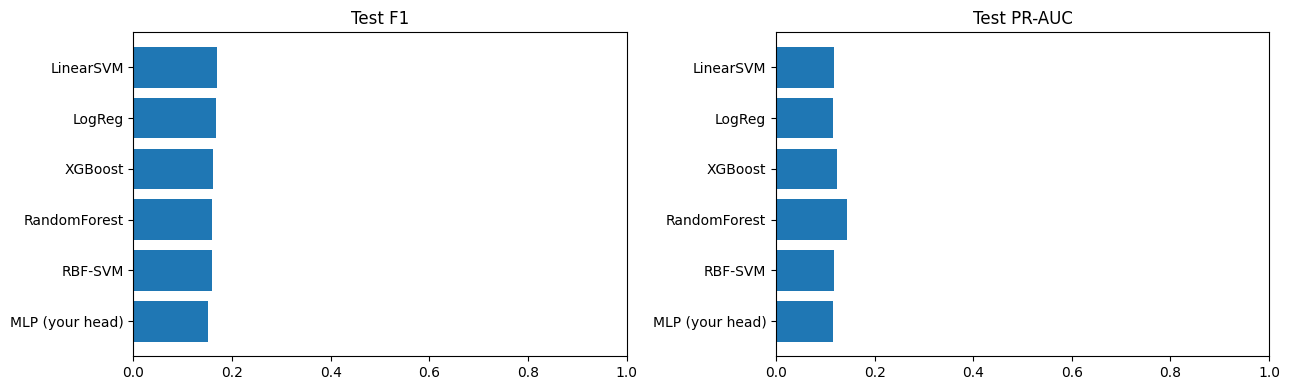

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
r = results.sort_values("test_f1")
ax[0].barh(r["model"], r["test_f1"]); ax[0].set_title("Test F1"); ax[0].set_xlim(0, 1)
ax[1].barh(r["model"], r["test_pr_auc"]); ax[1].set_title("Test PR-AUC"); ax[1].set_xlim(0, 1)
plt.tight_layout(); plt.show()

## Ghi chú

- Đây là feature từ encoder **đóng băng** (chưa fine-tune theo task) → kết quả là **baseline**; đừng ngạc nhiên nếu F1 chỉ ở mức trung bình. Nếu sau này fine-tune cả encoder, chỉ cần chạy lại Giai đoạn 1 để có file `.npz` "task-adapted" rồi Giai đoạn 2 giữ nguyên.
- Train cân bằng (`train_downsampling`) nhưng test lệch lớp → **PR-AUC/MCC** đáng tin hơn accuracy. Có thể chỉnh ngưỡng quyết định trên validation để tối ưu F1 nếu cần.
- Muốn fair tuyệt đối cho RBF-SVM (bỏ subsample) thì dùng xấp xỉ `Nystroem + LinearSVC` thay cho `SVC(kernel="rbf")` — scale tuyến tính theo số mẫu.
